<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/Avcad_Assignment_Exercise5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORTED LIBARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    chi2_contingency,
    kruskal,
    shapiro
)

from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
df = pd.read_csv("/content/EFIplus_medit.csv",sep=';')



**### BROWN TROUT PRESENCE/ABSENCE**

In [ ]:

print(df.columns)


Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect',
       'Calib_hydrol',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=164)


In [ ]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [ ]:
df.columns = df.columns.str.strip()
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB
None


In [ ]:
df['temp_ann'] = pd.to_numeric(df['temp_ann'], errors='coerce')
df['Elevation_mean_catch'] = pd.to_numeric(df['Elevation_mean_catch'], errors='coerce')

**### SEPERATE GROUPS**

In [ ]:
df['BrownTrout'] = df['Salmo trutta fario']
presence = df[df['BrownTrout'] == 1]['temp_ann'].dropna()
absence = df[df['BrownTrout'] == 0]['temp_ann'].dropna()


**## TEST NORMALITY**

In [ ]:
print(shapiro(presence))
print(shapiro(absence))

t_stat, p_value = ttest_ind(presence, absence)

print("T-statistic:", t_stat)
print("P-value:", p_value)

ShapiroResult(statistic=np.float64(0.944234929038207), pvalue=np.float64(5.569994259789673e-32))
ShapiroResult(statistic=np.float64(0.9740450645174886), pvalue=np.float64(4.6440721755782766e-18))
T-statistic: -43.45438419732505
P-value: 0.0


The Shapiro-Wilk test indicates that the temperature data is not normally distributed in both groups (p < 0.05). Despite this, an independent t-test was performed as requested. The results show a statistically significant difference in mean annual temperature between presence and absence sites (t = -43.45, p < 0.001). Therefore, the null hypothesis is rejected.

## INDEPENDENT T-TEST

In [ ]:
scaler = StandardScaler()

df['temp_ann_std'] = scaler.fit_transform(df[['temp_ann']])

presence_std = df[df['BrownTrout'] == 1]['temp_ann_std'].dropna()
absence_std = df[df['BrownTrout'] == 0]['temp_ann_std'].dropna()

t_stat_std, p_value_std = ttest_ind(presence_std, absence_std)

print("Standardized T-statistic:", t_stat_std)
print("Standardized P-value:", p_value_std)

Standardized T-statistic: -43.45438419732502
Standardized P-value: 0.0


## MANN-WHITNEY U TEST

In [ ]:
u_stat, p_value = mannwhitneyu(presence, absence)

print("U-statistic:", u_stat)
print("P-value:", p_value)

U-statistic: 1027812.5
P-value: 7.105075261935899e-303


A Mann–Whitney U test was performed as a non-parametric alternative to the t-test due to violation of normality assumptions. The results showed a statistically significant difference in mean annual temperature between presence and absence sites (U = 1,027,812.5, p < 0.001). This confirms the findings of the t-test.

##CHI-SQUARE TEST

In [ ]:
table = pd.crosstab(df['Country'], df['BrownTrout'])
print(table)

BrownTrout     0     1
Country               
France        13    59
Italy        109    76
Portugal     615   252
Spain       1239  2648


In [ ]:
chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 496.3723854072799
P-value: 2.9162328651936495e-107


## ALLUVIAL SANKAY

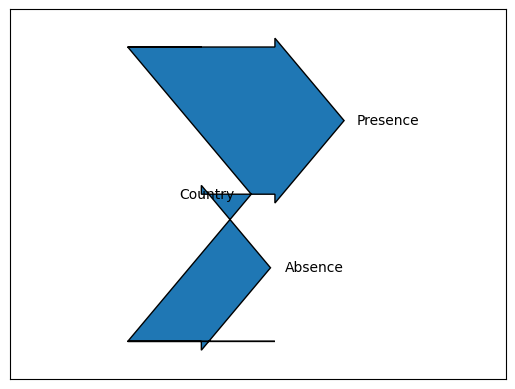

In [ ]:

Sankey(unit=None).add(
    flows=[1, -0.5, -0.5],
    labels=['Country', 'Presence', 'Absence']
).finish()

plt.show()

In [ ]:
df['Elevation_mean_catch'] = pd.to_numeric(df['Elevation_mean_catch'], errors='coerce')

#Then rebuild dataset:

df8 = df[df['Catchment_name'].isin(top8)].copy()
df8 = df8.dropna(subset=['Elevation_mean_catch'])

## ANOVA TEST

In [ ]:
top8 = df['Catchment_name'].value_counts().head(8).index

df_top8 = df[df['Catchment_name'].isin(top8)]

model = ols(
    'Elevation_mean_catch ~ C(Catchment_name)',
    data=df_top8
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)


tukey = pairwise_tukeyhsd(
    endog=df_top8['Elevation_mean_catch'],
    groups=df_top8['Catchment_name'],
    alpha=0.05
)

print(tukey)

                         sum_sq      df           F         PR(>F)
C(Catchment_name)  2.137395e+08     7.0  227.953983  1.369526e-285
Residual           5.315097e+08  3968.0         NaN            NaN
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1       group2    meandiff p-adj lower upper reject
-----------------------------------------------------------
  Cantabrica       Catala      nan   nan   nan   nan  False
  Cantabrica        Douro      nan   nan   nan   nan  False
  Cantabrica         Ebro      nan   nan   nan   nan  False
  Cantabrica Galiza-Norte      nan   nan   nan   nan  False
  Cantabrica       Guadia      nan   nan   nan   nan  False
  Cantabrica        Minho      nan   nan   nan   nan  False
  Cantabrica         Tejo      nan   nan   nan   nan  False
      Catala        Douro      nan   nan   nan   nan  False
      Catala         Ebro      nan   nan   nan   nan  False
      Catala Galiza-Norte      nan   nan   nan   nan  False
      Catala       

##DATA CLEANING REMOVE ROWS WHERE ELEVATION_MEAN_CATCH IS (NAN)

In [ ]:

df8['Elevation_mean_catch'] = pd.to_numeric(df8['Elevation_mean_catch'], errors='coerce')
df8 = df8.dropna(subset=['Elevation_mean_catch'])

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df8['Elevation_mean_catch'],
    groups=df8['Catchment_name'],
    alpha=0.05
)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

 KRUSKAL- WALLIS TEST AND COMPARISM BETWEEN ANOVA

In [ ]:
groups = []

for catch in top8:
    vals = df_top8[
        df_top8['Catchment_name'] == catch
    ]['Elevation_mean_catch'].dropna()

    groups.append(vals)

kruskal_result = kruskal(*groups)

print(kruskal_result)

KruskalResult(statistic=np.float64(1335.3732750709976), pvalue=np.float64(3.7056116510329714e-284))
